In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [4]:
#JOB ARRAY SETUP
job_array=True
if job_array==True:

    num_jobs=60 #150 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    total_elements=len(parcel['xh']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()
    
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
    start_job, end_job = get_job_range(job_id, num_jobs)
    index_adjust=start_job
    print(f'start_job = {start_job}, end_job = {end_job}')

start_job = 0, end_job = 16667


In [158]:
#Indexing Array with JobArray
parcel=parcel.isel(xh=slice(start_job,end_job))
#(for 150_000_000 parcels use 500-1000 jobs)

In [3]:
# Reading Back Data Later
##############
def make_data_dict(var_names,read_type):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            # data_dict = {var_name: f[var_name][:,start_job:end_job] for var_name in var_names} #USE THIS ONE
            data_dict = {var_name: f[var_name][:] for var_name in var_names}
            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        # data_dict = {k: in_data[k][:,start_job:end_job].compute().data for k in var_names} #USE THIS ONE
        data_dict = {k: in_data[k][:].compute().data for k in var_names}
    return data_dict

# read_type='xarray'
read_type='h5py'

In [4]:
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['A_g', 'A_c', 'W', 'Z', 'Y', 'X']
data_dict = make_data_dict(var_names,read_type)
A_g, A_c, W, Z, Y, X = (data_dict[k] for k in var_names)
# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)
check_memory(globals())

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'Normalize': '0.0 MB', 'MaxNLocator': '0.0 MB', 'ScalarFormatter': '0.0 MB', 'FuncAnimation': '0.0 MB'}

5.852 GB in use overall


In [5]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'VARS_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['QV','TH']
data_dict = make_data_dict(var_names,read_type)
QV, TH = (data_dict[k] for k in var_names)
check_memory(globals())

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'QV': '532.0 MB', 'TH': '532.0 MB', 'Normalize': '0.0 MB', 'MaxNLocator': '0.0 MB'}

6.916 GB in use overall


In [6]:
##########################
#SETUP SECTION

In [7]:
zfs=data['zf'].data*1000
times=(data['time'].data / 1e9).astype(int)
Nt=len(data['time'])

In [9]:
##########################
#BUILDING HISTOGRAM FUNCTIONS

In [10]:
# def SetupHistSampling(histz_vals, histt_vals):
#     # Process z levels
#     histz_str = np.array([str(z) for z in histz_vals])
#     histz = np.clip(np.searchsorted(zfs, histz_vals) - 1, 0, None)

#     # Process t levels
#     histt_str = np.array([str(t) for t in histt_vals])
#     histt_idx = np.clip(np.searchsorted(times, histt_vals, side='right') - 1, 0, None)
#     histt = [np.arange(0, ind + 1) for ind in histt_idx]

#     return histz, histt, histt_str, histz_str

#TESTING
def get_intervals_from_edges(histt_vals):
    extended = [0] + list(histt_vals)  # Add 0 as the starting point
    return [(extended[i], extended[i + 1]) for i in range(len(extended) - 1)]
def SetupHistSampling(histz_vals, histt_vals,UP_TO):
    # Process z levels
    histz_str = np.array([str(z) for z in histz_vals])
    histz = np.clip(np.searchsorted(zfs, histz_vals) - 1, 0, None)

    # Process t levels
    histt_str = np.array([str(t) for t in histt_vals])
    if UP_TO==True:
        histt_idx = np.clip(np.searchsorted(times, histt_vals, side='right') - 1, 0, None)
        histt = [np.arange(0, ind + 1) for ind in histt_idx]
        intervals=[(0,int(val)) for val in histt_vals] #only needed for plotting
    elif UP_TO==False:
        intervals = get_intervals_from_edges(histt_vals)
        histt_idx = np.clip(np.searchsorted(times, intervals, side='right') - 1, 0, None) #*#*#
        histt = [np.arange(start, end + 1) for start, end in histt_idx]

    print(histt)
    return histz, histt, histt_str, histz_str, intervals

In [11]:
#INITIALIZE ALL HISTOGRAMS IN A DICTIONARY
def MakeDictionary(histz_str,histt_str,hist_size):
    
    # Create a 2D zero-initialized array (this is your histogram storage array)
    zero_histogram = np.zeros(hist_size,dtype=int)
    
    # Initialize a dictionary to store the histograms
    Histograms = {}
    #store each histogram in a dictionary
    for z in histz_str:
        for t in histt_str:        
            Histograms[f"{z}_{t}"] = np.copy(zero_histogram)
    
    return Histograms
# [bin_left1,bin_right1,num_bins1]=GetBinSettings(VAR1_name)
# [bin_left2,bin_right2,num_bins2]=GetBinSettings(VAR2_name)
# hist_size = (num_bins1,num_bins2)  

In [ ]:
# #TESTING #*#*
# arr=qv_lst.copy()
# overall_min = np.min(np.concatenate(arr))
# overall_max = np.max(np.concatenate(arr))
# print("Min:", overall_min*1000)
# print("Max:", overall_max*1000)

# arr=th_lst.copy()
# overall_min = np.min(np.concatenate(arr))
# overall_max = np.max(np.concatenate(arr))
# print("Min:", overall_min)
# print("Max:", overall_max)

# # ==>
# #QV
# #Min: 10.992669500410557
# #Max: 17.3798818141222
# #TH
# #Min: 301.20013
# #Max: 310.33856
# #W
# # Min: -5.313181
# # Max: 6.396657

In [12]:
#HISTOGRAM SETTINGS
def GetBinSettings(var_name):    
    nbin1=250;nbin2=250
    
    # pre_calculated=False
    pre_calculated=True
    if pre_calculated==False:
        bin_settings = {
            'qv':       (QV.min(), QV.max(), nbin1),
            'th':       (TH.min(), TH.max(), nbin2),
            'w':        (W.min(), W.max(), nbin1),
            
        }
    elif pre_calculated==True:
        bin_settings = {
            'qv': (10/1000, 18/1000, nbin2),
            'th': (300, 311, nbin2),
            'w': (-6, 7, nbin1),
        }
    # Select bin range based on var_name
    if var_name is not None and var_name in bin_settings:
        bin_left, bin_right, num_bins = bin_settings[var_name]
    else:
        # fallback default
        bin_left, bin_right, num_bins = -50, 50, 1000
    return bin_left,bin_right,num_bins

In [13]:
# def MakeHistogram(VAR1s,VAR2s,bin_left,bin_right,num_bins): #TEST VERSION
#     Output=np.ones((5000,5000),dtype=int)
#     return Output

def MakeHistogram(VAR1s,VAR2s,
                  bin_left1,bin_right1,num_bins1,
                  bin_left2,bin_right2,num_bins2): #*#*
    ###given two flattened arrays, will bin each value into 2D Histograms

    # Output =np.zeros((num_bins2, num_bins1)) 
    # bin_list1=np.linspace(bin_left1,bin_right1,num_bins1)
    # bin_list2=np.linspace(bin_left2,bin_right2,num_bins2)
    
    # Define bin edges
    bins_list1 = np.linspace(bin_left1, bin_right1, num_bins1 + 1)
    bins_list2 = np.linspace(bin_left2, bin_right2, num_bins2 + 1)

    # Compute 2D histogram
    Output, xedges, yedges = np.histogram2d(VAR2s, VAR1s, bins=[bins_list2, bins_list1])
    return Output.astype(int)

In [14]:
##########################
#BUILDING ALGORITHM FUNCTIONS

In [15]:
class BreakException(Exception):
    pass
def _BREAK_(var=None):
    print(var)
    raise BreakException 

#GET LAGRANGIAN SPATIAL ARRAYS
def GetSpace(t, p):#, X, Y, Z):
    z = Z[t, p]; zs = Z[t] 
    y = Y[t, p]; ys = Y[t]
    x = X[t, p]; xs = X[t]
    return z,y,x,zs,ys,xs

def SpaceConditional(z,y,x,D,zs,ys,xs):
    cond1 = D==1; cond2 = zs==z; 
    cond3 = ys==y; cond4 = xs==x
    #where the entrained parcels are in same grid box
    where=cond1&cond2&cond3&cond4 
    # print(np.where(cond1),np.where(cond2),np.where(cond3),np.where(cond4))
    # print(np.where(cond1&cond2&cond3))
    return where

#####
def Meshgrid_Advanced(ts, ps):
    t_grid, p_grid = np.meshgrid(ts, ps)
    return t_grid.flatten(), p_grid.flatten()

def SubsetZ(histz,t_lst,p_lst):
    Zs=Z[t_lst,p_lst]
    where_z = np.where(np.isin(Zs,histz))[0]
    t_lst=t_lst[where_z];p_lst=p_lst[where_z]
    return t_lst,p_lst,Zs

In [16]:
#FIND ENTRAINMENT PARCELS
def GetEntrainmentHistory(A,VAR1,VAR2,Dictionary,t,p):
    global qv_lst,th_lst #TESTING #*#*
    if t<=histt[-1][-1]:
        return Dictionary

    #marking entrained parcels
    D=A[t] - A[t-1]
    D=np.where(D>0,True,False)
    # _BREAK_(D)

    #getting some spatial variables
    [z,y,x,zs,ys,xs] = GetSpace(t,p)
    # _BREAK_((z,y,x,zs,ys,xs))
    if z not in histz:
        return Dictionary
    z_string=histz_str[histz == z][0]
    
    #locating entrained parcels 
    where = SpaceConditional(z,y,x,D,zs,ys,xs)
    # _BREAK_(np.where(where==True))
    ps=np.where(where)
    if ps[0].size==0:
        return Dictionary
    # else: #TESTING #*#*
    #     print(f'found particles at p={p}')
    #     # _BREAK_(ps)

    #get trackback trajectories
    for (ts,t_string) in zip(histt,histt_str):
        #meshgrid calculations 
        minus_ts=(t - ts)[(t - ts) < Nt]
        # _BREAK_((minus_ts,ps))
        [t_flat,p_flat] = Meshgrid_Advanced(minus_ts, ps)
        
        # _BREAK_(t_flat)

        #get variable data along trajectory
        VAR1s = VAR1[t_flat,p_flat]
        VAR2s = VAR2[t_flat,p_flat]

        qv_lst.append(VAR1s);th_lst.append(VAR2s)#TESTING #*#*

        # _BREAK_((VAR1s,VAR2s))

        #ADD HISTOGRAM TO A DICTIONARY
        Histogram = MakeHistogram(VAR1s,VAR2s,
                  bin_left1,bin_right1,num_bins1,
                  bin_left2,bin_right2,num_bins2)
        # _BREAK_(np.where(Histogram!=0))
        Dictionary[f'{z_string}_{t_string}'] += Histogram

    #return the updated dictionary
    return Dictionary
        

In [17]:
##########################
#LOADING DATA

In [18]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'

# Reading Back Data Later
##################################################################
#DOMAIN SUBSETTING
def DOMAIN_SUBSET(out_arr):
    print(f'length before: {len(out_arr)}')

    #SETTING UP
    ###########
    ocean_percent=2/8
    left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
    where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
    where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
    end_xh=len(data['xh'])-1-50
    end_xf=len(data['xf'])-1-50
    
    print(f'x in {0}:{where_coast_xh-1} FOR SEA')
    print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
    
    t_start=36 
    t_end=len(data['time']) # if res=='250m': t_end=410
    print(f't in {t_start}:end (8 hours)')

    #SUBSETTING CODE
    ################
    t,p=out_arr[:,1],out_arr[:,0]
    if 'job_array' in globals():
        p -= index_adjust

    #GETTING X VALUES OF EACH PARCEL 
    fancy_index=True
    # fancy_index=False
    if fancy_index==True:
        xs=X[t,p] #FANCY INDEXING
    elif fancy_index==False: #(slightly longer, but avoids loading X into memory)
        with h5py.File(in_file, 'r') as f:
            xs=[]
            for i, j in zip(t, p):
                xs.append(f['X'][i, j])
            xs=np.array(xs)
    ################
    
    out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
    out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

    print(f'==> length after: {len(out_arr)}'+'\n')
    return out_arr

In [21]:
#LOADING BACK IN
def load_file():
    in_file=dir+f'Project_Algorithms/Tracking_Algorithms/parcel_tracking_{res}_{t_res}_{Np_str}.h5'
    with h5py.File(in_file, 'r') as hf:
        out_arr=hf['out_arr'][:]
        save_arr=hf['save_arr'][:]
        save2_arr=hf['save2_arr'][:]
    return out_arr,save_arr,save2_arr
[out_arr,save_arr,save2_arr]=load_file()

print('list of first 10 ignored parcels');
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels'+'\n')

if 'job_array' in globals():
    #APPLYING JOB_ARRAY TO PARCEL NUMBER
    ####################################
    def job_filter(arr):
        return arr[(arr[:,0]>=start_job)&(arr[:,0]<end_job)]
    print('Applying Job Array')
    out_arr=job_filter(out_arr)
    save_arr=job_filter(save_arr)

print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels'+'\n')

#CHOOSING UNIQUE INDEXES
###############################################################################
def remove_duplicates(arr):
    lst = []
    unique_values, counts = np.unique(arr[:, 0], return_counts=True)
    duplicates = unique_values[counts > 1]
    for elem in duplicates:
        idx = np.where(arr[:, 0] == elem)[0]
        extras = idx[np.where(arr[idx, 1] != np.min(arr[idx, 1]))]
        lst.extend(extras)
    mask = np.ones(len(arr), dtype=bool)
    mask[lst] = False
    return arr[mask]
out_arr=remove_duplicates(out_arr)
save_arr=remove_duplicates(save_arr)
###############################################################################

############################################################
#SUBSETTING
subset=True
if subset==True:
    out_arr=DOMAIN_SUBSET(out_arr)
    save_arr=DOMAIN_SUBSET(save_arr)
############################################################

ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 ignored parcels
there are a total of 14754 CL parcels and 14545 nonCL parcels

there are a total of 14754 CL parcels and 14545 nonCL parcels

length before: 14754
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
==> length after: 14708

length before: 14545
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
==> length after: 11034



In [23]:
#...... more data loading #*#*

In [24]:
##########################
#USER SET PARAMETERS

In [218]:
#ENTRAINMENT TYPE SET
type='general'
# type='cloudy

#VARIABLE SETUP
VAR1=QV.copy();VAR1_name='qv'; 
VAR2=TH.copy();VAR2_name='th';
VAR2=W.copy();VAR2_name='w';

#HISTOGRAM SETUP PARAMETERS
histz_vals=[200,500,1000] #unit: meters
histt_vals=[200,400,600,800,1000] #unit:seconds

In [219]:
##########################
#SETTING UP SOME THINGS

In [220]:
#DATA SETUP
ARR=ALL_out_arr.copy()
A = A_c.copy() if type == 'cloudy' else A_g.copy()
# t_lst=ARR[:,1]; p_lst=ARR[:,0] #only includes the first tiemstep of trajectory (old)
tp_coords=np.vstack([np.column_stack((np.repeat(p, t2 - t1 + 1), np.arange(t1, t2 + 1))) for p, t1, t2 in ARR])
t_lst = tp_coords[:,1]; p_lst=tp_coords[:,0]

In [221]:
#SET HISTOGRAMS HERE
[bin_left1,bin_right1,num_bins1]=GetBinSettings(VAR1_name)
[bin_left2,bin_right2,num_bins2]=GetBinSettings(VAR2_name)
hist_size = (num_bins2,num_bins1)  

#HISTOGRAM INFO
UP_TO=True
# UP_TO=False
[histz, histt, histt_str, histz_str, intervals] = SetupHistSampling(histz_vals, histt_vals, UP_TO=UP_TO) #goes from 0 up to time
[t_lst,p_lst,Zs]=SubsetZ(histz,t_lst,p_lst)#SUBSETTING DATA FOR Zs in histz (FOR FASTER SPEED)
print(histz,histt)

#INITIALIZE HISTOGRAMS
Dictionary = MakeDictionary(histz_str,histt_str,hist_size)

[array([0]), array([0, 1]), array([0, 1, 2]), array([0, 1, 2]), array([0, 1, 2, 3])]
[2 4 6] [array([0]), array([0, 1]), array([0, 1, 2]), array([0, 1, 2]), array([0, 1, 2, 3])]


In [222]:
# #TESTING THE ALGORITHM IS WORKING CORRECTLY 
# #ALSO TURN ON OLD MakeHistogram FUNCTION
# values, counts = np.unique(Zs[np.isin(Zs,histz)], return_counts=True)
# print(values)
# print(counts)

In [223]:
##########################
#RUNNING
qv_lst=[];th_lst=[] #TESTING #*#*

In [224]:
for count,(t,p) in enumerate(zip(t_lst,p_lst)):
    if count % 500 == 0: print(f"{count}/{len(p_lst)}")
    Dictionary = GetEntrainmentHistory(A,VAR1,VAR2,Dictionary,t,p)
    # _BREAK_()

0/21882
500/21882
1000/21882
1500/21882
2000/21882
2500/21882
3000/21882
3500/21882
4000/21882
4500/21882
5000/21882
5500/21882
6000/21882
6500/21882
7000/21882
7500/21882
8000/21882
8500/21882
9000/21882
9500/21882
10000/21882
10500/21882
11000/21882
11500/21882
12000/21882
12500/21882
13000/21882
13500/21882
14000/21882
14500/21882
15000/21882
15500/21882
16000/21882
16500/21882
17000/21882
17500/21882
18000/21882
18500/21882
19000/21882
19500/21882
20000/21882
20500/21882
21000/21882
21500/21882


In [155]:
################
#SAVING
import pickle
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
out_file=dir2+f"Entrainment_Trackback_{UP_TO}_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}_{job_id}.h5"
with open(out_file, "wb") as f:
    pickle.dump(Dictionary, f)

In [108]:
################
#RECOMBINING
recombine=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
# recombine=True

In [109]:
if recombine==True:
    def GetData(job_id):
        out_file=dir2+f"Entrainment_Trackback_{UP_TO}_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}_{job_id}.h5"
        with open(out_file, "rb") as f:
            Dictionary = pickle.load(f)
        return Dictionary

    UP_TO=True
    # UP_TO=False
    VAR1_name='qv'
    VAR2_name='th'
    VAR2_name='w'
    import pickle
    dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
    
    num_jobs=350
    job_id=1;Dictionary=GetData(job_id)
    for job_id in np.arange(2,num_jobs+1):
        for key in Dictionary:
            Dictionary[key]+=GetData(job_id)

        

In [191]:
################
#PLOTTING
plotting=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
plotting=True

In [228]:
if plotting==True:
    UP_TO=True
    # UP_TO=False
    VAR1_name='qv'
    VAR2_name='th';VAR2_unit='(K)'
    VAR2_name='w';VAR2_unit='(m/s)'
    dir2=dir+'Project_Algorithms/Tracked_Profiles/'
    in_file=dir2+f"Entrainment_Trackback_{UP_TO}_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}.h5"
    
    import pickle
    with open(out_file, "rb") as f:
        Dictionary = pickle.load(f)

In [229]:
if plotting==True:
    histz_vals=[200,500,1000] #unit: meters
    histt_vals=[200,400,600,800,1000] #unit:seconds
    [histz, histt, histt_str, histz_str, intervals] = SetupHistSampling(histz_vals, histt_vals, UP_TO=UP_TO) #goes from 0 up to time
    print(intervals)

[array([0]), array([0, 1]), array([0, 1, 2]), array([0, 1, 2]), array([0, 1, 2, 3])]
[(0, 200), (0, 400), (0, 600), (0, 800), (0, 1000)]


In [230]:
#PLOTTING FUNCTIONS
def histogram2d_colors():
    colors_rgb = [
        [44, 87, 169],    # Blue 1
        [54, 92, 171],    # Blue 2
        [66, 97, 175],    # Blue 3
        [67, 107, 182],   # Blue 4
        [70, 117, 187],   # Blue 5
        [70, 125, 193],   # Blue 6
        [74, 140, 204],   # Blue 7
        [76, 157, 216],   # Blue 8
        [75, 178, 232],   # Blue 9
        [78, 192, 242],   # Blue 10
        [110, 201, 242],   # Blue 11
        [140, 207, 240],   # Blue 12
        [161, 219, 245],   # Blue 13
        [190, 226, 226],   # Blue 14
    
        [40, 150, 40],    # Green 1
        [60, 160, 60],    # Green 2
        [80, 180, 80],    # Green 3
        [120, 200, 120],  # Green 4
        
        # [225, 237, 178],   # Yellow 1
        [244, 239, 125],   # Yellow 2
        [247, 232, 75],   # Yellow 3
        [249, 213, 43],   # Yellow 4
        [247, 194, 14],   # Orange 1
        [245, 178, 15],   # Orange 2
        [242, 159, 19],   # Orange 4
        [238, 141, 22],   # Orange 5
        [236, 121, 26],   # Orange 6
        
        [230, 77, 34],   # Red 1
        [229, 51, 35],   # Red 2
        [228, 37, 30],   # Red 3
        [220, 29, 32],   # Red 4
        [205, 28, 32],   # Red 5
        
    ]
    colors = [[c / 255 for c in color] for color in colors_rgb]
    
    # #TESTING
    # custom_cmap = mcolors.ListedColormap(colors)
    
    # # Create an array to display the colorbar
    # data = np.linspace(0, 1, len(colors)).reshape(1, -1)
    
    # # Plotting the colorbar
    # fig, ax = plt.subplots(figsize=(10, 2))
    # cbar = ax.imshow(data, cmap=custom_cmap, aspect='auto')
    # ax.set_axis_off() 
    return colors

In [231]:
#PLOTTING FUNCTIONS
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

def initialize_colorbar(bin_array, num_contour_levels):
    colors = histogram2d_colors()
    custom_cmap = mcolors.ListedColormap(colors)
    custom_cmap.set_under("white")
    levels = np.linspace(np.min(bin_array), np.max(bin_array), num_contour_levels)
    norm = BoundaryNorm(levels, len(colors))
    return custom_cmap, norm, levels

# [custom_cmap, norm, levels]=initialize_colorbar(bin_array, num_contour_levels=30)

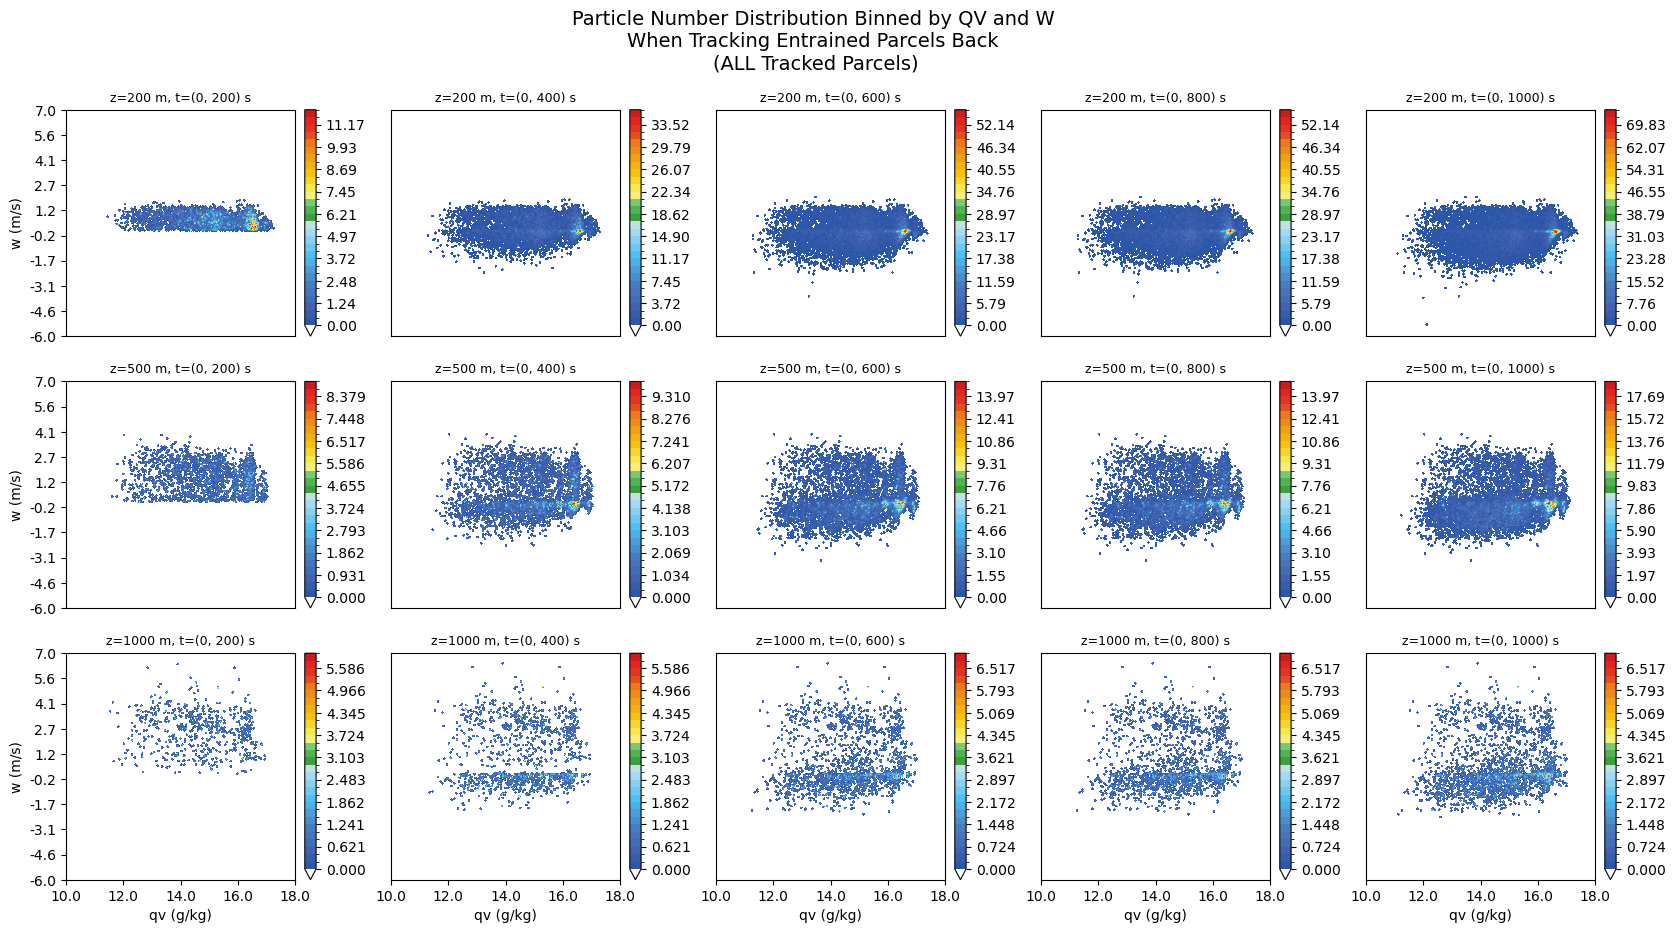

In [232]:
if plotting == True:
    def format_axes(ax, i, j, nrows, ncols, bin_array, xlabel="X-axis label", ylabel="Y-axis label"):
        if i == nrows - 1:
            num_bins=5
            ax.set_xlabel(xlabel)
            x_ticks_positions=np.linspace(bin_left1*1000,bin_right1*1000,num_bins)
            ax.set_xticks(np.linspace(0,bin_array.shape[1],num_bins));
            ax.set_xticklabels([f'{p:.1f}' for p in x_ticks_positions]);
        else:
            ax.set_xticks([])
    
        if j == 0:
            num_bins=10
            ax.set_ylabel(ylabel)
            y_ticks_positions=np.linspace(bin_left2,bin_right2,num_bins)
            ax.set_yticks(np.linspace(0,bin_array.shape[1],num_bins));
            ax.set_yticklabels([f'{p:.1f}' for p in y_ticks_positions]);
        else:
            ax.set_yticks([])


    def plot_histogram_grid(data_dict, histz_vals, histt_vals, xlabel,ylabel):
        fig = plt.figure(figsize=(20, 10))
        gs = gridspec.GridSpec(len(histz_vals), len(histt_vals), figure=fig, wspace=0.3, hspace=0.2)
    
        for i, z in enumerate(histz_vals):
            for j, (t, t_int) in enumerate(zip(histt_vals,intervals)):
                key = f'{z}_{t}'
                ax = fig.add_subplot(gs[i, j])
                
                if key in data_dict:
                    bin_array = data_dict[key]
                    [custom_cmap, norm, levels] = initialize_colorbar(bin_array, num_contour_levels=30)
                    im = ax.contourf(bin_array, levels=levels, cmap=custom_cmap, norm=norm, extend='min')
                    
                    ax.set_title(f'z={z} m, t={t_int} s', fontsize=9)
                    format_axes(ax, i, j, len(histz_vals), len(histt_vals), 
                                bin_array, xlabel=xlabel, ylabel=ylabel)
                    fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
                else:
                    ax.axis('off')
    
        fig.suptitle(f'Particle Number Distribution Binned by QV and {VAR2_name.upper()} \nWhen Tracking Entrained Parcels Back \n(ALL Tracked Parcels)', fontsize=14)
    
    histz_vals = ['200', '500', '1000']  # unit: meters
    histt_vals = ['200', '400', '600', '800', '1000']  # unit: seconds
    plot_histogram_grid(Dictionary, histz_vals, histt_vals, xlabel="qv (g/kg)",ylabel=f"{VAR2_name} {VAR2_unit}")

In [202]:
#OLD TESTING

In [ ]:
# #TESTING
# for key in Dictionary:
#     if np.where(Dictionary[key]!=0):
#         print(key)

In [533]:
# #TESTING
# def GetTZYX(ARR):
#     Ts=ARR[:,1]
#     Zs=Z[t_lst,p_lst]
#     Ys=Y[t_lst,p_lst]
#     Xs=X[t_lst,p_lst]
#     return Ts,Zs,Ys,Xs
# Ts,Zs,Ys,Xs=GetTZYX(ARR)